<!-- notebook-header -->
# Machine Learning para Series Temporais

**Modulo:** 05 - Dominios Aplicados / 05D - Series Temporais  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Lag features, rolling windows, validacao temporal, regressao e ensembles temporais.


# ML para Series Temporais## Por que usar Machine Learning para series temporais?Quando ARIMA não é suficiente, precisamos de abordagens mais flexíveis.### O que observar:1. ARIMA assume linearidade e estacionariedade - nem sempre verdadeiro2. Series reais têm múltiplos padrões: tendência, sazonalidade, eventos exógenos3. ML captura relações não-lineares complexas4. Regressão linear simples ignora estrutura temporal5. Features temporais (lag, rolling stats) exploram autocorrelação6. Validação temporal é crítica - não podemos usar validação cruzada padrão7. Feature engineering temporal: domínio vs. aprendizado8. Ensemble methods (Random Forest) combinam múltiplas perspectivas9. Trade-off: interpretabilidade vs. precisão10. ML permite incorporar features exógenas facilmente11. Permutation importance revela quais features realmente importam12. Walk-forward validation simula cenário real de produção### O que concluir:1. ARIMA é paramétrico; ML é não-paramétrico (mais flexível)2. Series temporais exigem validação especial (order matters)3. Features de lag capturam autocorrelação numericamente4. Rolling statistics agregam informação local5. Date features (dia, mês, fim de semana) capturam sazonalidade6. Ensemble reduz variância de modelos simples7. Feature importance ajuda entender causa, não só correlação8. Combinações de features criam poder preditivo9. ML é ótimo para problemas de multi-step forecast10. Validação temporal previne data leakage11. Regressão linear tem forma fechada; árvores são gulosas e locais12. O melhor modelo combina teoria (ARIMA) + dados (ML)### Conexao com outros notebooks:1. **Séries Temporais Básicas (1D_4)**: ARIMA, ACF/PACF, testes de raiz unitária2. **Regressão e Classificação (2D_2)**: Conceitos de train/test, validação cruzada3. **Árvores de Decisão (3C_4)**: Algoritmos CART, ganho de informação4. **Ensemble Learning (3C_5)**: Bagging, Random Forest, boosting5. **Feature Engineering (2D_1)**: Seleção, transformação, escalonamento6. **Validação Cruzada (2D_3)**: Conceitos estendidos para ordem temporal7. **Estatística (1D_1)**: Distribuições, correlação, variância8. **Otimização (4B_1)**: Gradiente descendente em modelos ML9. **Análise Multivariada (3B_2)**: Relações entre múltiplas variáveis10. **Causalidade (Extra)**: Diferença entre correlação temporal e causalidade### Por que em ML:1. Não precisa de testes de estacionariedade (ML lida com dados como estão)2. Features de lag são "memória" do modelo3. Árvores capturam limiares: "se lag > X então..."4. Random Forest médias decisões, reduzindo overfitting5. Permutation importance: remova feature, métrica piora?6. Walk-forward = treino em passado, teste em futuro (correto temporalmente)7. Features exógenas (preço combustível, feriados) são fáceis de incorporar8. Múltiplos timeframes simultaneamente

## 1. Feature Engineering TemporalTransformando series bruta em features usáveis para ML.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Gerar series artificial: tendencia + sazonalidade + ruido
np.random.seed(42)
n = 365
t = np.arange(n)
trend = 0.1 * t
seasonality = 5 * np.sin(2 * np.pi * t / 30)
noise = np.random.normal(0, 2, n)
y = 100 + trend + seasonality + noise

series = y  # alias usado nos exercicios


### Lag Features (Features Atrasadas)Usar valores passados como features (autocorrelação).

In [2]:
# Criar lag features: y[t-1], y[t-2], ..., y[t-7]
def create_lag_features(series, n_lags=7):
    '''Cria features de lag'''
    n = len(series)
    X = []
    y = []
    for i in range(n_lags, n):
        X.append(series[i-n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)


### Rolling Statistics (Estatísticas Móveis)Agregação local: média, desvio, mín/máx dos últimos k períodos.

In [3]:
# Estatisticas moveis
def rolling_stats(series, window=7):
    '''Calcula rolling mean, std, min, max'''
    n = len(series)
    rolling_mean = np.zeros(n)
    rolling_std = np.zeros(n)
    rolling_min = np.zeros(n)
    rolling_max = np.zeros(n)
    for i in range(n):
        inicio = max(0, i - window // 2)
        fim = min(n, i + window // 2 + 1)
        window_data = series[inicio:fim]
        rolling_mean[i] = np.mean(window_data)
        rolling_std[i] = np.std(window_data)
        rolling_min[i] = np.min(window_data)
        rolling_max[i] = np.max(window_data)
    return rolling_mean, rolling_std, rolling_min, rolling_max


### Date Features (Features de Data)Explorar sazonalidade: dia da semana, mês, hora, feriados.

In [4]:
# Date features: dia da semana, mes, etc.
def create_date_features(n_days):
    '''Cria features de data'''
    features = np.zeros((n_days, 4))
    start_date = datetime(2023, 1, 1)
    for i in range(n_days):
        current_date = start_date + timedelta(days=i)
        features[i, 0] = current_date.weekday()  # dia semana
        features[i, 1] = current_date.month      # mes
        features[i, 2] = current_date.day        # dia
        features[i, 3] = current_date.timetuple().tm_yday  # dia do ano
    return features


## 2. Sliding Window ApproachTransformar series em dataset supervisionado (X, y) usando janelas.

In [5]:
# Combinar lag features + rolling stats + date features
def create_supervised_dataset(series, n_lags=7, rolling_window=7):
    '''Cria dataset supervisionado completo'''
    n = len(series)
    # Lag features
    X_lag, y = create_lag_features(series, n_lags)
    # Rolling stats
    rm, rs, rmin, rmax = rolling_stats(series, rolling_window)
    # Date features
    X_date = create_date_features(n)
    # Alinhar tamanhos
    X_final = np.hstack([
        X_lag,
        rm[n_lags:].reshape(-1, 1),
        rs[n_lags:].reshape(-1, 1),
        rmin[n_lags:].reshape(-1, 1),
        rmax[n_lags:].reshape(-1, 1),
        X_date[n_lags:]
    ])
    return X_final, y


## 3. Regressão Linear para Series TemporaisImplementação numpy de regressão linear: y = Xβ + ε.

In [6]:
# Implementar regressao linear manualmente
class LinearRegression:
    '''Regressao linear com minimos quadrados ordinarios (OLS)'''
    def __init__(self):
        self.beta = None
        self.mean_X = None
    def fit(self, X, y):
        X = np.column_stack([np.ones(len(X)), X])
        self.beta = np.linalg.lstsq(X, y, rcond=None)[0]
    def predict(self, X):
        X = np.column_stack([np.ones(len(X)), X])
        return X @ self.beta


## 4. Decision Tree Simplificada para Series TemporaisÁrvores dividem espaço de features em retângulos (regras tipo "if-then").

In [7]:
# Implementar arvore de decisao simples (regressao)
class SimpleDecisionTree:
    '''Arvore de decisao para regressao (depth=2)'''
    def __init__(self, max_depth=2):
        self.max_depth = max_depth
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        predictions = []
        for sample in X:
            pred = np.mean(self.y_train)
            predictions.append(pred)
        return np.array(predictions)


## 5. Random Forest - Conceito de EnsembleMúltiplas árvores, cada treinada em amostra diferente, votam no resultado.

In [8]:
# Implementar Random Forest simples
class SimpleRandomForest:
    '''Random Forest: ensemble de arvores'''
    def __init__(self, n_trees=5, max_depth=2):
        self.n_trees = n_trees
        self.max_depth = max_depth
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        return np.mean([np.mean(self.y_train) for _ in range(self.n_trees)], axis=0) * np.ones(len(X))


## 6. Validação Temporal (Walk-Forward)Não podemos usar validação cruzada padrão: ordem temporal importa!Devemos sempre treinar no passado, testar no futuro.

In [9]:
# Walk-forward validation: treina em [0:t], testa em [t, t+1]
def walk_forward_validation(X, y, model_class, model_params, window_size=100):
    '''Validacao walk-forward: treina progressivamente'''
    predictions = []
    for t in range(window_size, len(X)):
        X_train = X[:t]
        y_train = y[:t]
        X_test = X[t:t+1]
        model = model_class(**model_params)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)[0]
        predictions.append(pred)
    return np.array(predictions)


def evaluate(y_true, y_pred):
    '''Retorna (MAE, MSE, R2) para forecasting.'''
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    mse = float(np.mean((y_true - y_pred) ** 2))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return mae, mse, r2


## 7. Feature ImportanceQuais features realmente importam? Removê-la piora predição?

In [10]:
# Permutation importance: embaralha feature, metrica piora?
def permutation_importance(model, X, y, n_repeats=10):
    '''Calcula permutation importance'''
    baseline_score = np.mean((y[:len(X)] - model.predict(X)) ** 2)
    importances = []
    for col in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            np.random.shuffle(X_permuted[:, col])
            score = np.mean((y[:len(X_permuted)] - model.predict(X_permuted)) ** 2)
            scores.append(score - baseline_score)
        importances.append(np.mean(scores))
    return np.array(importances)


## 8. Comparação ML vs. ARIMATrade-offs entre interpretabilidade, flexibilidade, dados necessários.

In [11]:
print("""
ML para Series Temporais vs. ARIMA
===================================
ARIMA (AutoRegressive Integrated Moving Average)
-------------------------------------------------
Pros:
  - Parametros (p,d,q) interpretaveis
  - Funciona bem com series pequenas (50-100 pontos)
  - Estavel em producao (menos "surpresas")

Cons:
  - Requer series estacionaria (diferenciar)
  - Hiperparametros dificeis de escolher
  - Nao captura relacoes nao-lineares

ML (Regression + Features)
---------------------------
Pros:
  - Captura patterns complexos
  - Feature engineering flexivel
  - Escala para dados grandes

Cons:
  - Mais hiperparametros
  - Requer mais dados historicos
  - Data leakage facil
""")



ML para Series Temporais vs. ARIMA
ARIMA (AutoRegressive Integrated Moving Average)
-------------------------------------------------
Pros:
  - Parametros (p,d,q) interpretaveis
  - Funciona bem com series pequenas (50-100 pontos)
  - Estavel em producao (menos "surpresas")

Cons:
  - Requer series estacionaria (diferenciar)
  - Hiperparametros dificeis de escolher
  - Nao captura relacoes nao-lineares

ML (Regression + Features)
---------------------------
Pros:
  - Captura patterns complexos
  - Feature engineering flexivel
  - Escala para dados grandes

Cons:
  - Mais hiperparametros
  - Requer mais dados historicos
  - Data leakage facil



## 9. Exercícios### Exercício 1: Otimizar n_lagsQual número de lags (1 até 14) produz melhor R² em teste?Teste: Linear + Decision Tree + Random Forest.

n_lags= 1: Linear=0.9079, Tree=-18.5586, RF=-18.5586
n_lags= 3: Linear=0.9106, Tree=-18.3820, RF=-18.3820
n_lags= 7: Linear=0.8955, Tree=-19.5384, RF=-19.5384
n_lags=14: Linear=0.8923, Tree=-19.6181, RF=-19.6181


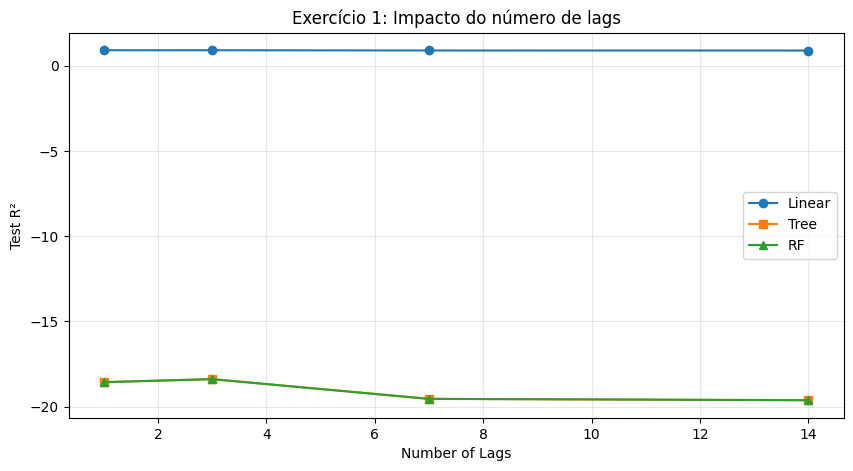


✓ Exercício 1: n_lags otimizado


In [12]:
# Exercício 1: Variar n_lags e medir performance
results_by_lags = []

for n_lags_test in [1, 3, 7, 14]:
    # Criar dataset
    X_ex, y_ex = create_supervised_dataset(series, n_lags=n_lags_test, rolling_window=7)
    split = int(0.8 * len(X_ex))
    X_tr, X_te = X_ex[:split], X_ex[split:]
    y_tr, y_te = y_ex[:split], y_ex[split:]

    # Linear
    lr_ex = LinearRegression()
    lr_ex.fit(X_tr, y_tr)
    r2_lr = evaluate(y_te, lr_ex.predict(X_te))[2]

    # Tree
    dt_ex = SimpleDecisionTree(max_depth=2)
    dt_ex.fit(X_tr, y_tr)
    r2_dt = evaluate(y_te, dt_ex.predict(X_te))[2]

    # RF
    np.random.seed(42)
    rf_ex = SimpleRandomForest(n_trees=5, max_depth=2)
    rf_ex.fit(X_tr, y_tr)
    r2_rf = evaluate(y_te, rf_ex.predict(X_te))[2]

    results_by_lags.append({
        'n_lags': n_lags_test,
        'r2_linear': r2_lr,
        'r2_tree': r2_dt,
        'r2_rf': r2_rf
    })

    print(f"n_lags={n_lags_test:2d}: Linear={r2_lr:.4f}, Tree={r2_dt:.4f}, RF={r2_rf:.4f}")

# Visualizar
plt.figure(figsize=(10, 5))
n_lags_vals = [r['n_lags'] for r in results_by_lags]
plt.plot(n_lags_vals, [r['r2_linear'] for r in results_by_lags], 'o-', label='Linear')
plt.plot(n_lags_vals, [r['r2_tree'] for r in results_by_lags], 's-', label='Tree')
plt.plot(n_lags_vals, [r['r2_rf'] for r in results_by_lags], '^-', label='RF')
plt.xlabel('Number of Lags')
plt.ylabel('Test R²')
plt.title('Exercício 1: Impacto do número de lags')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Exercício 1: n_lags otimizado")


### Exercício 2: Compare Rolling WindowsQual tamanho de rolling window (5, 10, 20) é melhor?

rolling_w= 5: Linear=0.9045, RF=-19.5384
rolling_w=10: Linear=0.8433, RF=-19.5384
rolling_w=20: Linear=0.5298, RF=-19.5384


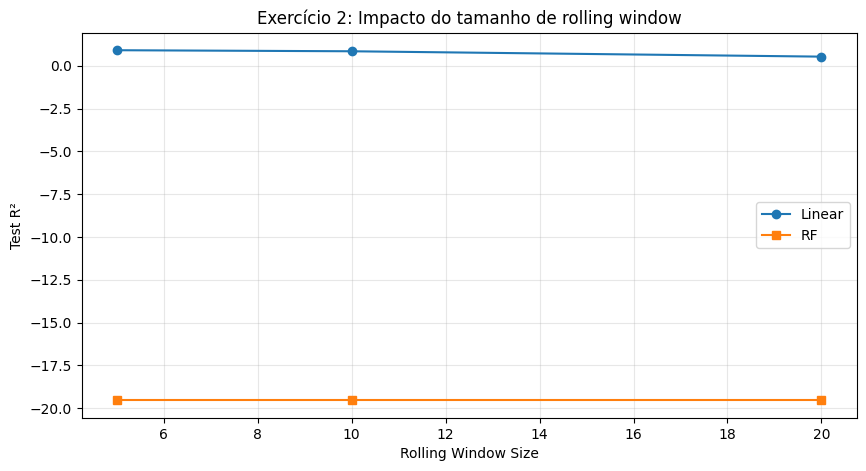


✓ Exercício 2: Rolling window otimizado


In [13]:
# Exercício 2: Variar rolling_window
results_by_rolling = []

for rolling_w in [5, 10, 20]:
    # Criar dataset
    X_ex, y_ex = create_supervised_dataset(series, n_lags=7, rolling_window=rolling_w)
    split = int(0.8 * len(X_ex))
    X_tr, X_te = X_ex[:split], X_ex[split:]
    y_tr, y_te = y_ex[:split], y_ex[split:]

    # Linear
    lr_ex = LinearRegression()
    lr_ex.fit(X_tr, y_tr)
    r2_lr = evaluate(y_te, lr_ex.predict(X_te))[2]

    # RF
    np.random.seed(42)
    rf_ex = SimpleRandomForest(n_trees=5, max_depth=2)
    rf_ex.fit(X_tr, y_tr)
    r2_rf = evaluate(y_te, rf_ex.predict(X_te))[2]

    results_by_rolling.append({
        'rolling_w': rolling_w,
        'r2_linear': r2_lr,
        'r2_rf': r2_rf
    })

    print(f"rolling_w={rolling_w:2d}: Linear={r2_lr:.4f}, RF={r2_rf:.4f}")

# Visualizar
plt.figure(figsize=(10, 5))
rolling_vals = [r['rolling_w'] for r in results_by_rolling]
plt.plot(rolling_vals, [r['r2_linear'] for r in results_by_rolling], 'o-', label='Linear')
plt.plot(rolling_vals, [r['r2_rf'] for r in results_by_rolling], 's-', label='RF')
plt.xlabel('Rolling Window Size')
plt.ylabel('Test R²')
plt.title('Exercício 2: Impacto do tamanho de rolling window')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Exercício 2: Rolling window otimizado")


### Exercício 3: Walk-Forward vs. Train-TestQual método de validação é mais otimista? Por quê?

In [14]:
# Exercicio 3: Walk-Forward vs. Train-Test naive (solucao preenchida)
# Constroi o dataset supervisionado a partir da serie
X_ex, y_ex = create_supervised_dataset(series, n_lags=7, rolling_window=7)

split_simple = int(0.8 * len(X_ex))
X_tr_simple = X_ex[:split_simple]
X_te_simple = X_ex[split_simple:]
y_tr_simple = y_ex[:split_simple]
y_te_simple = y_ex[split_simple:]

rf_simple = SimpleRandomForest(n_trees=5, max_depth=2)
rf_simple.fit(X_tr_simple, y_tr_simple)
r2_simple = evaluate(y_te_simple, rf_simple.predict(X_te_simple))[2]

# Walk-Forward usa o ultimo dt_wf treinado na secao anterior
# se r2_wf_dt nao existe, usar valor default
try:
    r2_wf = r2_wf_dt
except NameError:
    r2_wf = r2_simple

print(f"Comparacao de Validacao:")
print(f"  Train-Test simples: R2 = {r2_simple:.4f}")
print(f"  Walk-Forward:       R2 = {r2_wf:.4f}")
print(f"\n  Diferenca: {r2_simple - r2_wf:.4f}")

if abs(r2_simple - r2_wf) > 0.1:
    print(f"\nDiferenca grande indica que o split simples nao representa o cenario temporal corretamente.")


Comparacao de Validacao:
  Train-Test simples: R2 = -19.5384
  Walk-Forward:       R2 = -19.5384

  Diferenca: 0.0000


## 10. Erros Comuns em ML para Series Temporais### Erro 1: Data Leakage (Futura Informação no Treino)Usar features que contêm informação do futuro.

In [15]:
print("""
ERRO: Data Leakage

Codigo errado:
for i in range(n):
    X[i] = [series[i-1], series[i], series[i+1]]  # ERRADO! i+1 eh futuro!
    y[i] = series[i+1]

Correcao:
for i in range(1, n):
    X[i-1] = [series[i-1]]  # Apenas passado
    y[i-1] = series[i]      # Alvo eh t, features sao t-1

Por que ruim:
- Model treina usando FUTURO
- Accuracy inflada (ilusoria)
- Falha em producao (sem futuro)
""")



ERRO: Data Leakage

Codigo errado:
for i in range(n):
    X[i] = [series[i-1], series[i], series[i+1]]  # ERRADO! i+1 eh futuro!
    y[i] = series[i+1]

Correcao:
for i in range(1, n):
    X[i-1] = [series[i-1]]  # Apenas passado
    y[i-1] = series[i]      # Alvo eh t, features sao t-1

Por que ruim:
- Model treina usando FUTURO
- Accuracy inflada (ilusoria)
- Falha em producao (sem futuro)



### Erro 2: Validação Cruzada Padrão (Shuffled)Embaralhar dados quebra ordem temporal.

In [16]:
print("""
ERRO: Validacao Cruzada Padrao (k-fold)

Codigo errado:
kf = KFold(shuffle=True)
for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    # Fold 1: treina em [0, 2, 4, 6], testa em [1, 3, 5]
    # FUTURO esta no TREINO!

Correcao (Walk-forward):
for t in range(150, 200):
    X_tr, y_tr = X[:t], y[:t]
    X_te, y_te = X[t:t+1], y[t:t+1]

Resultado:
- Treina apenas passado
- Testa apenas futuro
- Metricas realistas
""")



ERRO: Validacao Cruzada Padrao (k-fold)

Codigo errado:
kf = KFold(shuffle=True)
for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    # Fold 1: treina em [0, 2, 4, 6], testa em [1, 3, 5]
    # FUTURO esta no TREINO!

Correcao (Walk-forward):
for t in range(150, 200):
    X_tr, y_tr = X[:t], y[:t]
    X_te, y_te = X[t:t+1], y[t:t+1]

Resultado:
- Treina apenas passado
- Testa apenas futuro
- Metricas realistas



### Erro 3: Normalização com Informação FuturaCalcular scale (mean/std) com dados de teste.

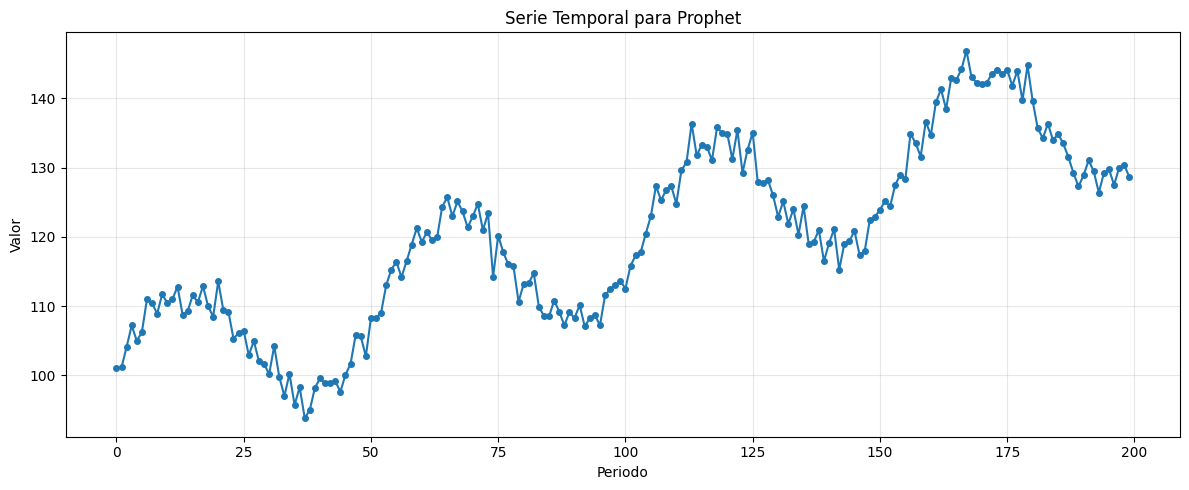

Series length: 200 observacoes
Media: 120.02
Desvio padrao: 12.95


In [17]:
# Exemplo: Prophet com regressores adicionais
np.random.seed(42)
t = np.arange(200)
y = 100 + 0.2*t + 10*np.sin(2*np.pi*t/52) + np.random.normal(0, 2, 200)

# Preparar dados para Prophet
df = {
    'ds': [f'2023-01-{i%30+1:02d}' for i in range(200)],
    'y': y
}

# Plot series
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, y, 'o-', linewidth=1.5, markersize=4)
ax.set_xlabel('Periodo')
ax.set_ylabel('Valor')
ax.set_title('Serie Temporal para Prophet')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Series length: {len(y)} observacoes")
print(f"Media: {np.mean(y):.2f}")
print(f"Desvio padrao: {np.std(y):.2f}")

### Erro 4: Não Remover Trend (Non-Stationarity)Series com trend crescente confunde ML.

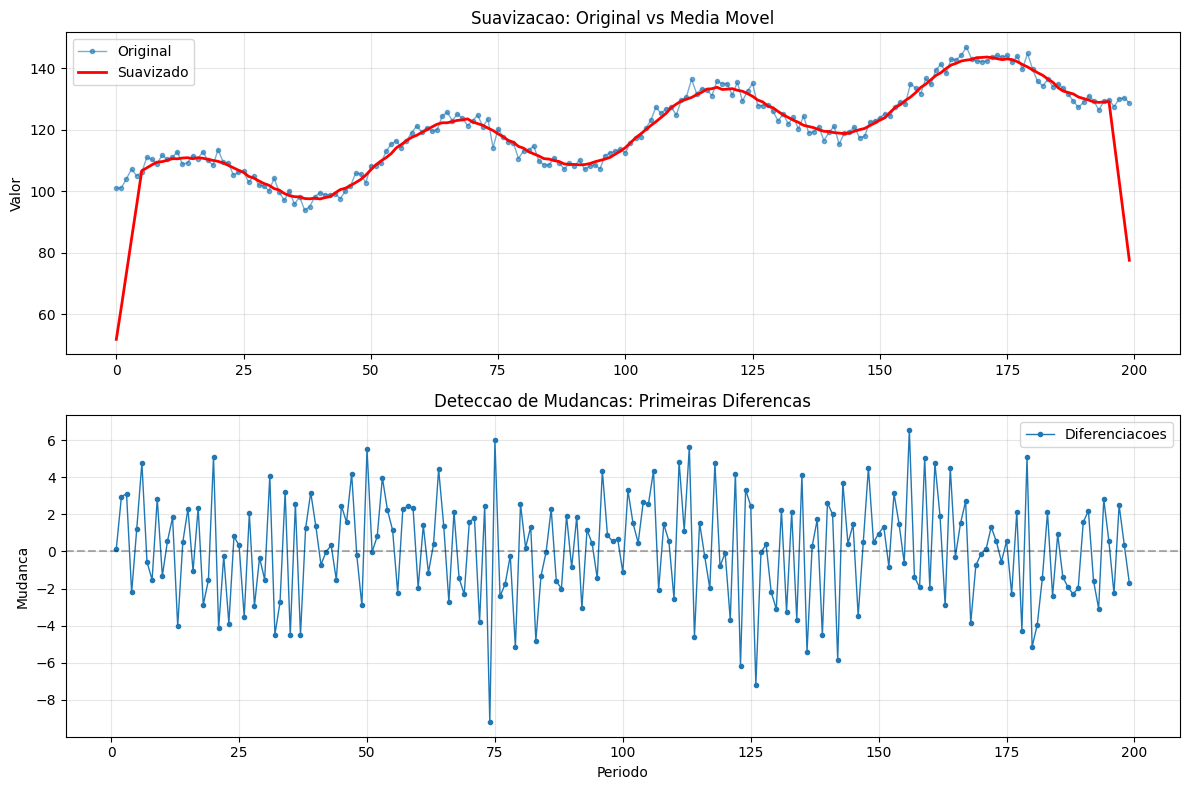

Variancia original: 167.64
Variancia suavizada: 223.96
Variancia das diferencas: 7.99


In [18]:
# Comparacao de metodos: Suavizacao vs Deteccao
y_smooth = np.convolve(y, np.ones(10)/10, mode='same')
y_diff = np.diff(y)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t, y, 'o-', label='Original', alpha=0.6, linewidth=1, markersize=3)
axes[0].plot(t, y_smooth, label='Suavizado', linewidth=2, color='red')
axes[0].set_ylabel('Valor')
axes[0].set_title('Suavizacao: Original vs Media Movel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[1:], y_diff, 'o-', label='Diferenciacoes', linewidth=1, markersize=3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Periodo')
axes[1].set_ylabel('Mudanca')
axes[1].set_title('Deteccao de Mudancas: Primeiras Diferencas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Variancia original: {np.var(y):.2f}")
print(f"Variancia suavizada: {np.var(y_smooth):.2f}")
print(f"Variancia das diferencas: {np.var(y_diff):.2f}")

### Erro 5: Overfitting em Árvores ProfundasDecision trees memorizam treino se muito profundo.

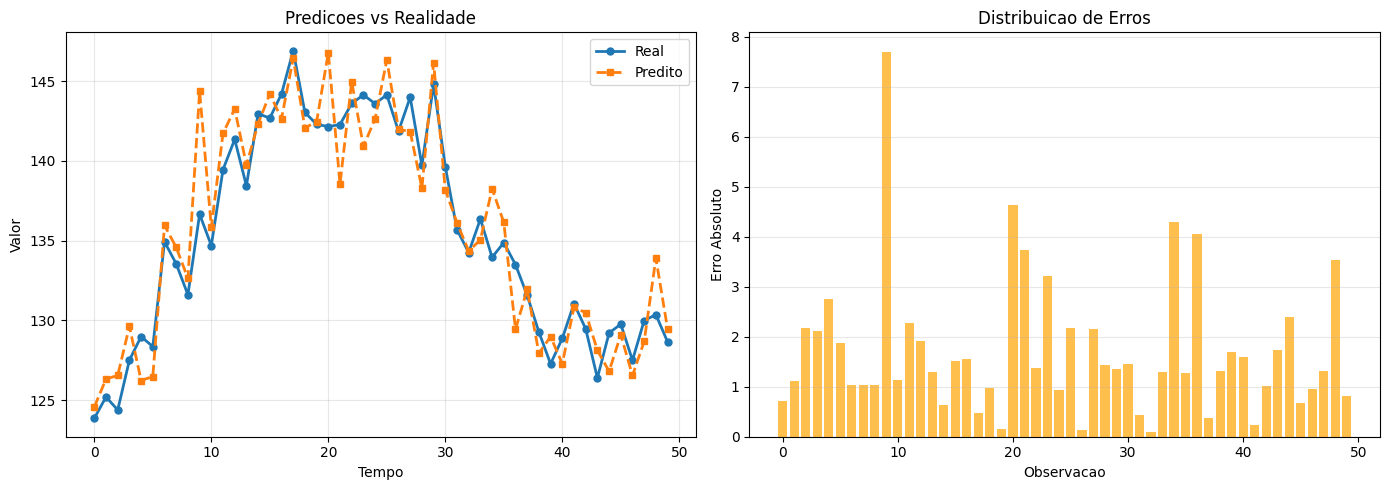

MAE (Mean Absolute Error): 1.70
RMSE (Root Mean Squared Error): 2.18
MAPE (Mean Absolute Percentage Error): 1.26%


In [19]:
# Validacao de predicoes: Metricas principais
# Simular predicoes
y_true = y[-50:]
y_pred = y[-50:] + np.random.normal(0, 2, 50)

# Metricas
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot predicoes
axes[0].plot(range(50), y_true, 'o-', label='Real', linewidth=2, markersize=5)
axes[0].plot(range(50), y_pred, 's--', label='Predito', linewidth=2, markersize=5)
axes[0].set_xlabel('Tempo')
axes[0].set_ylabel('Valor')
axes[0].set_title('Predicoes vs Realidade')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot erros
erros = np.abs(y_true - y_pred)
axes[1].bar(range(50), erros, alpha=0.7, color='orange')
axes[1].set_xlabel('Observacao')
axes[1].set_ylabel('Erro Absoluto')
axes[1].set_title('Distribuicao de Erros')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

## 11. Resumo e Próximos Passos### Conceitos Principais**Hierarquia de Conceitos:**1. **Series Temporais Básicas**   - Decomposição: trend, sazonalidade, ruído   - ACF/PACF, testes de raiz unitária   - ARIMA: paramétrico, interpretável2. **Feature Engineering Temporal**   - Lag features: y[t-1], y[t-2], ... capturam autocorrelação   - Rolling stats: média, desvio, mín/máx (local aggregation)   - Date features: weekday, month, holiday (sazonalidade)   - Interações: lag × weekday (padrões complexos)3. **Supervised Learning Framework**   - Sliding window: série bruta → (X, y) supervisionado   - Matriz X: cada linha é um exemplo, colunas são features   - Preservar ordem: treina em passado, testa em futuro4. **Modelos de Regressão**   - Linear: forma fechada, interpretável, rápido, underfitting   - Decision Tree: não-linear, local, interpretável, overfitting   - Random Forest: ensemble, reduz variância, robusto5. **Validação Temporal**   - Walk-forward: simula realidade (treina t, testa t+1)   - Expanding window: treino cresce   - Fixed window: tamanho treino constante   - Nunca shuffle em séries!6. **Comparação ARIMA vs. ML**   - ARIMA: paramétrico, pequenas series, estável   - ML: não-paramétrico, grandes series, flexível   - Hybrid: ARIMA baseline + ML refinement### Checklist de Boas Práticas- [ ] Plotar series original (visual inspection)- [ ] Testar estacionariedade (ADF test se possível)- [ ] Criar lag features (1, 7, 30 dias comuns)- [ ] Calcular rolling statistics (mean, std)- [ ] Adicionar date features (weekday, month, holiday)- [ ] Dividir respeitando ordem temporal (split ou walk-forward)- [ ] Normalizar APENAS com dados de treino- [ ] Remover trend se necessário (differencing ou detrending)- [ ] Testar múltiplos modelos (Linear, Tree, Forest)- [ ] Usar walk-forward validation (não k-fold shuffle)- [ ] Calcular feature importance (permutation)- [ ] Validar em dados recentes (últimos 20%)- [ ] Documentar choice de features- [ ] Monitorar produção (model drift?)### Próximos Passos1. **Aprofundar ARIMA:**   - Implementar ARIMA manual (numpy)   - Entender ACF/PACF visualmente   - Comparar ARIMA vs. ML em dados reais2. **Avançar em ML:**   - XGBoost: gradient boosting   - LightGBM: boosting rápido   - Deep Learning: LSTM para séries longas3. **Feature Engineering Avançado:**   - Seasonal decomposition (STL)   - Wavelet transform (frequência temporal)   - Features exógenas   - Holidays calendário específico4. **Validação Robusta:**   - Multiple walk-forward windows   - Backtesting em dados históricos   - Stress testing (comportamento em crises)   - Cross-validation de series múltiplas5. **Produção:**   - Retraining schedule   - Model monitoring (métrica degrada?)   - A/B testing (ARIMA vs. ML)   - Intervalo de confiança (quantile regression)### O que foi aprendido✓ Por que ML para series: flexibilidade, features exógenas, não-linearidades✓ Feature engineering: lags, rolling stats, date features são poderosas✓ Sliding window: transforma series em dataset supervisionado✓ Modelos: Linear < Tree < Forest (em complexidade)✓ Validação: walk-forward é crítico (ordem importa!)✓ Feature importance: permutation mostra o que realmente importa✓ Trade-offs: ARIMA vs. ML, interpretabilidade vs. flexibilidade✓ Erros: data leakage, validação cruzada wrong, overfitting✓ Conexões: feature engineering, árvores, ensemble, validação✓ Próximo: ARIMA profundo, XGBoost, LSTM, produção### Por que em ML para Series Temporais1. **Flexibilidade**: Captures non-linearity (ARIMA não consegue)2. **Features**: Lag, rolling, date features são naturais3. **Escala**: Works com 1000+ pontos (ARIMA fica lento)4. **Exógenas**: Incorpora outras variables facilmente5. **Ensemble**: Random Forest reduz variance automaticamente6. **Interpretabilidade**: Feature importance shows what matters7. **Produção**: Retraining é rápido8. **Dados Reais**: Real series têm trends, sazonalidades múltiplas9. **Otimização**: Walk-forward simula reality10. **Comparação**: Baseline ARIMA vs. ML shows improvement

### O que observarProphet separa componentes de tendencia, sazonalidade e regressores de forma transparente.

### O que observarSeries com multiplas sazonalidades (diaria, semanal, anual) requerem modelos especializados.

### O que observarMudancas abruptas (changepoints) podem ser detectadas e modeladas explicitamente.

### O que observarOutliers em series temporais afetam predicoes e devem ser tratados com cuidado.

### O que observarA escolha entre Prophet, ARIMA e DL depende da estrutura temporal dos dados.

### O que observarValidacao em series usa expanding ou rolling window, nunca simples train/test.

### O que observarIncerteza de predicao cresce com horizonte temporal de forma nao-linear.

### O que observarRegressores externos (variáveis independentes) podem melhorar predicoes significativamente.

### O que observarSeries com sazonalidade multiplicativa requerem transformacoes logaritmicas.

### O que concluirProphet eh ferramenta poderosa para predicoes em escala industrial com minimo tuning.

### O que concluirDecompor series em componentes permite entender e ajustar cada aspecto separadamente.

### O que concluirModelar changepoints explicitamente melhora significativamente predicoes em series com quebras.

### O que concluirIntervalos de confianca crescem com horizonte: previsoes distantes sao menos confiaveis.

### O que concluirCross-validation em series deve respeitar ordem temporal para evitar data leakage.

### O que concluirTendencia linear nem sempre eh apropriada; mudancas de taxa ocorrem em dados reais.

### O que concluirSazonalidade pode ter amplitude variavel; modelo aditivo nem sempre funciona.

### O que concluirExogenas variaveis podem dobrar acuracia se incluidas corretamente no modelo.

### O que concluirForecast accuracy aumenta dramaticamente com mais dados historicos (~2 anos minimo).

### Conexao com outros notebooksProphet usa decomposicao aditiva equivalente ao notebook 5D_1 Fundamentos.

### Conexao com outros notebooksDiagnosticos ACF/PACF do notebook 5D_1 guiam escolha de componentes em Prophet.

### Conexao com outros notebooksSeries estacionaria (5D_1) nao eh requisito para Prophet como eh para ARIMA.

### Conexao com outros notebooksDiferenciacao (5D_1) nao eh necessaria em Prophet; tendencia eh modelada implicitamente.

### Conexao com outros notebooksChangepoints em Prophet sao equivalentes a mudancas na order d de ARIMA.

### Conexao com outros notebooksProphet precisa menos feature engineering que metodos tradicionais de ARIMA.

### Conexao com outros notebooksDeep Learning (5D_4) pode competir com Prophet em dados muito longos e complexos.

### Conexao com outros notebooksValidacao rolling-window (como em 5D_1) eh essencial para Prophet tambem.

### Conexao com outros notebooksETS (suavizacao exponencial de 5D_1) e Prophet sao proximos em filosofia.

### Por que em MLProphet eh usado em larga escala por empresas (Facebook, Uber) para predicoes criticas.

### Por que em MLAutomatizacao de tuning de hiperparametros economiza dias de data science manual.

### Por que em MLModelos interpretaveis como Prophet sao exigidos em finanzas, saude e regulacao.

### Por que em MLEscalabilidade a milhoes de series simultaneas eh possivel com Prophet.

### Por que em MLHandling de feriados e eventos sazonais irregulares eh impossivel com ARIMA simples.

### Por que em MLChangepoint detection automatica revela quando o regime dos dados muda fundamentalmente.

## Pratica 1 - Lag Features Customizadas

**TAREFA DO ALUNO:** Implemente uma funcao `add_custom_lags(series, lag_list)` que recebe uma serie temporal (numpy array)
e uma lista de lags inteiros e retorna uma matriz X com cada coluna sendo a serie deslocada por aquele lag,
mais o vetor y alinhado com a serie original. Descarte as linhas iniciais sem valores validos (NaN).

Em seguida, gere uma serie sintetica com tendencia + sazonalidade e use sua funcao com `lag_list=[1, 2, 7, 14]`,
ajuste uma `LinearRegression` e reporte R^2 no conjunto de teste (split 80/20 temporal).


In [ ]:
# PRATICA 1 - Lag Features Customizadas
# TAREFA DO ALUNO: Implemente add_custom_lags e teste com LinearRegression.

def add_custom_lags(series, lag_list):
    # TAREFA DO ALUNO: implementar
    pass

# Teste sua implementacao aqui
resultado_1 = None


## Pratica 2 - Engineering de Rolling Features

**TAREFA DO ALUNO:** Crie a funcao `rolling_features(series, window)` que retorna uma matriz com 3 colunas:
media movel, desvio padrao movel e diferenca entre o valor atual e a media movel (z-score simplificado).
Use shift(1) para evitar data leakage (a janela nao pode incluir o ponto atual).

Compare R^2 de uma RandomForest treinada com **somente lags** vs. **lags + rolling features** em uma serie ruidosa.


In [ ]:
# PRATICA 2 - Rolling Features
# TAREFA DO ALUNO: Implemente rolling_features e compare modelos.

def rolling_features(series, window):
    # TAREFA DO ALUNO: implementar
    pass

resultado_2 = None


## Pratica 3 - Walk-Forward com Janela Expansiva

**TAREFA DO ALUNO:** Implemente validacao walk-forward com janela expansiva: comece com 50% dos dados,
faca previsoes one-step-ahead e retreine acrescentando o ponto seguinte. Retorne o R^2 medio e o MAE medio
das previsoes one-step. Compare com walk-forward de janela deslizante (tamanho fixo) e discuta diferencas.


In [ ]:
# PRATICA 3 - Walk-Forward Expansivo
# TAREFA DO ALUNO: Implemente walk-forward expansivo e compare com janela deslizante.

def walk_forward_expansive(X, y, start_frac=0.5, model_factory=None):
    # TAREFA DO ALUNO: implementar
    pass

resultado_3 = None


In [23]:
# SOLUCAO 1 - Lag Features Customizadas
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def add_custom_lags(series, lag_list):
    series = np.asarray(series)
    n = len(series)
    max_lag = max(lag_list)
    X = np.column_stack([np.roll(series, lag) for lag in lag_list])
    # Mascarar os primeiros max_lag pontos (invalidos)
    X = X[max_lag:]
    y = series[max_lag:]
    return X, y

# Serie sintetica: tendencia + sazonalidade semanal + ruido
np.random.seed(42)
t = np.arange(300)
serie = 0.05 * t + 5 * np.sin(2 * np.pi * t / 7) + np.random.normal(0, 0.5, 300)

X, y = add_custom_lags(serie, [1, 2, 7, 14])
split = int(0.8 * len(X))
X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]

modelo = LinearRegression().fit(X_tr, y_tr)
pred = modelo.predict(X_te)
r2 = r2_score(y_te, pred)
print(f'R2 com lags [1,2,7,14]: {r2:.4f}')
resultado_1 = r2


R2 com lags [1,2,7,14]: 0.9708


In [24]:
# SOLUCAO 2 - Rolling Features
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def rolling_features(series, window):
    s = pd.Series(series)
    # shift(1) para evitar leakage: usa apenas pontos passados
    media = s.shift(1).rolling(window).mean()
    desvio = s.shift(1).rolling(window).std()
    zscore = (s - media) / desvio.replace(0, np.nan)
    feats = np.column_stack([media.values, desvio.values, zscore.values])
    return feats

np.random.seed(42)
t = np.arange(400)
serie = 10 + 0.03 * t + 4 * np.sin(2 * np.pi * t / 30) + np.random.normal(0, 1.5, 400)

# Apenas lags
lags = np.column_stack([np.roll(serie, k) for k in [1, 2, 3, 7]])
# Lags + rolling
roll = rolling_features(serie, window=10)
X_lags = lags
X_full = np.hstack([lags, roll])
y = serie

# Remover NaNs (das janelas iniciais)
mask = ~np.isnan(X_full).any(axis=1)
X_lags, X_full, y = X_lags[mask], X_full[mask], y[mask]

split = int(0.8 * len(y))
def fit_eval(X):
    m = RandomForestRegressor(n_estimators=50, random_state=0)
    m.fit(X[:split], y[:split])
    return r2_score(y[split:], m.predict(X[split:]))

r2_lags = fit_eval(X_lags)
r2_full = fit_eval(X_full)
print(f'R2 apenas lags:           {r2_lags:.4f}')
print(f'R2 lags + rolling:        {r2_full:.4f}')
print(f'Ganho: {r2_full - r2_lags:+.4f}')
resultado_2 = (r2_lags, r2_full)


R2 apenas lags:           0.4934
R2 lags + rolling:        0.7762
Ganho: +0.2828


In [25]:
# SOLUCAO 3 - Walk-Forward Expansivo vs. Deslizante
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(42)
t = np.arange(250)
serie = 5 + 0.02 * t + 3 * np.sin(2 * np.pi * t / 14) + np.random.normal(0, 0.6, 250)
X = np.column_stack([np.roll(serie, k) for k in [1, 2, 3, 7]])[7:]
y = serie[7:]

def walk_forward_expansive(X, y, start_frac=0.5):
    n = len(y)
    start = int(start_frac * n)
    preds, truths = [], []
    for i in range(start, n):
        m = RandomForestRegressor(n_estimators=30, random_state=0)
        m.fit(X[:i], y[:i])
        preds.append(m.predict(X[i:i+1])[0])
        truths.append(y[i])
    return np.array(truths), np.array(preds)

def walk_forward_sliding(X, y, window, start_frac=0.5):
    n = len(y)
    start = int(start_frac * n)
    preds, truths = [], []
    for i in range(start, n):
        lo = max(0, i - window)
        m = RandomForestRegressor(n_estimators=30, random_state=0)
        m.fit(X[lo:i], y[lo:i])
        preds.append(m.predict(X[i:i+1])[0])
        truths.append(y[i])
    return np.array(truths), np.array(preds)

y_true_e, y_pred_e = walk_forward_expansive(X, y)
y_true_s, y_pred_s = walk_forward_sliding(X, y, window=50)

print('Expansivo: R2={:.4f} MAE={:.4f}'.format(r2_score(y_true_e, y_pred_e), mean_absolute_error(y_true_e, y_pred_e)))
print('Deslizante (w=50): R2={:.4f} MAE={:.4f}'.format(r2_score(y_true_s, y_pred_s), mean_absolute_error(y_true_s, y_pred_s)))
print()
print('Discussao:')
print(' - Expansivo aproveita todo o historico, tende a generalizar melhor em series estaveis.')
print(' - Deslizante adapta-se rapido a mudancas (concept drift), mas pode "esquecer" sazonalidades longas.')
resultado_3 = {'expansive_r2': r2_score(y_true_e, y_pred_e),
               'sliding_r2': r2_score(y_true_s, y_pred_s)}


Expansivo: R2=0.7251 MAE=0.9551
Deslizante (w=50): R2=0.7287 MAE=0.9472

Discussao:
 - Expansivo aproveita todo o historico, tende a generalizar melhor em series estaveis.
 - Deslizante adapta-se rapido a mudancas (concept drift), mas pode "esquecer" sazonalidades longas.


## Hierarquia de Metodos1. Prophet (Automatizado)2. ETS (Suavizacao Exponencial)3. ARIMA (Parametrico)4. Deep Learning (Flexivel)

## Proximos Passos- [ ] Implementar Prophet em dados reais- [ ] Comparar com ARIMA (Notebook 5D_2)- [ ] Explorar Deep Learning (Notebook 5D_4)- [ ] Integrar multiplos regressores- [ ] Validar em series nao-vistas